In [22]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
csv_filename = "../CleanData/full_test_05_09.csv"
df = pd.read_csv(csv_filename)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18242 entries, 0 to 18241
Data columns (total 88 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   site                  18242 non-null  object 
 1   daynight              18242 non-null  int64  
 2   attendance            18242 non-null  int64  
 3   temp                  18242 non-null  float64
 4   windspeed             18242 non-null  float64
 5   Home_Away             18242 non-null  int64  
 6   left_on_base          18242 non-null  int64  
 7   bat_doubles           18242 non-null  int64  
 8   bat_triples           18242 non-null  int64  
 9   bat_home_runs         18242 non-null  int64  
 10  bat_stolen_bases      18242 non-null  int64  
 11  passed_balls_allowed  18242 non-null  int64  
 12  errors_committed      18242 non-null  int64  
 13  stolen_bases          18242 non-null  int64  
 14  yearID                18242 non-null  int64  
 15  salary             

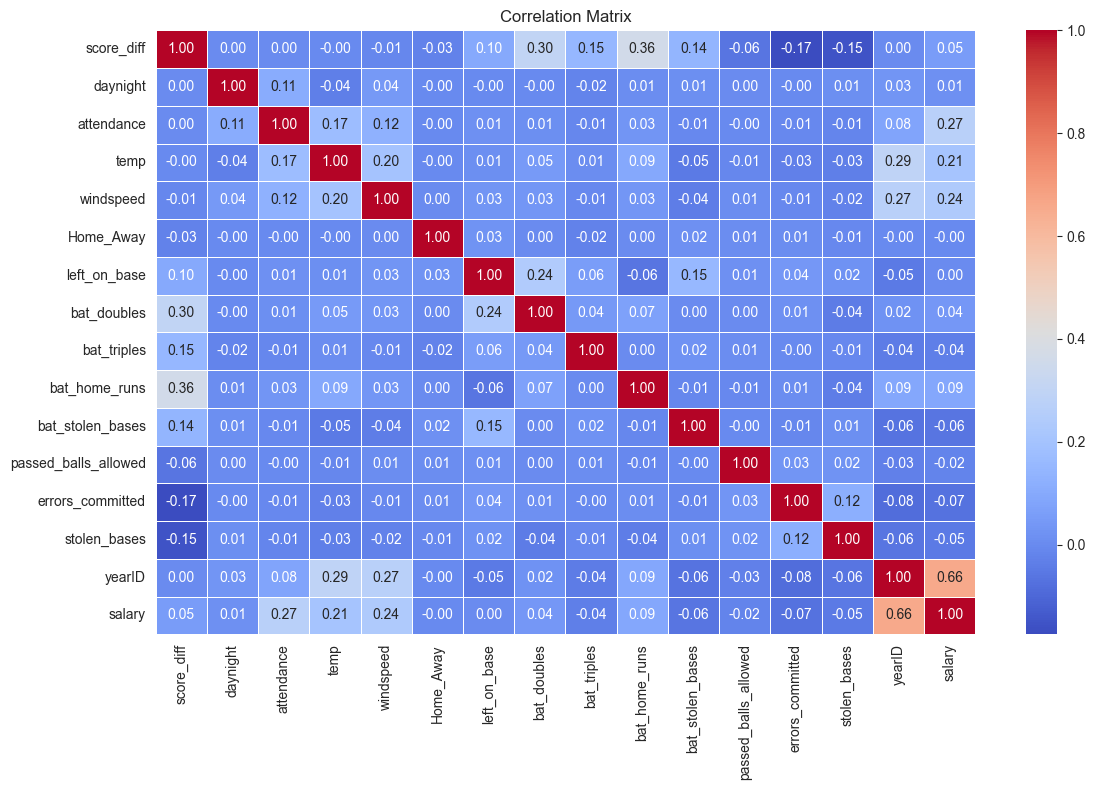

In [24]:
correlation_matrix = df.corr(numeric_only=True)

# Move 'score_diff' to the diagonal position
cols = [
    "daynight",
    "attendance",
    "temp",
    "windspeed",
    "Home_Away",
    "left_on_base",
    "bat_doubles",
    "bat_triples",
    "bat_home_runs",
    "bat_stolen_bases",
    "passed_balls_allowed",
    "errors_committed",
    "stolen_bases",
    "yearID",
    "salary",
]
cols = ['score_diff'] + cols
correlation_matrix = correlation_matrix[cols].loc[cols]

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [25]:
# correlation seems to be have between `score_diff` X ['Home_Away', 'left_on_base', 'bat_doubles', 'bat_triples', 'bat_home_runs', 'bat_stolen_bases', 'passed_balls_allowed', 'stolen_bases', 'salary', 'errors_committed', ]

columns_with_correlation = ['bat_stolen_bases', 'left_on_base', 'Home_Away', 'bat_doubles', 'bat_triples', 'bat_home_runs', 'salary', 'stolen_bases', 'errors_committed', 'passed_balls_allowed']

# pick only numeric columns for PCA
target = 'score_diff'
non_categorical_columns = []
categorical_columns = []
for c in df.columns:
    if c == target:
        continue
    if df[c].dtype == 'object' or df[c].dtype.name == 'category' or c == 'date':
        categorical_columns.append(c)
    else:
        non_categorical_columns.append(c)


# move yearID to the categorical
categorical_columns.append('yearID')
non_categorical_columns.remove('yearID')
categorical_columns.remove('site')  # it is one hot encoded

print(f"Categorical columns: {categorical_columns}")
print(f"Non-categorical columns: {non_categorical_columns}")


Categorical columns: ['yearID']
Non-categorical columns: ['daynight', 'attendance', 'temp', 'windspeed', 'Home_Away', 'left_on_base', 'bat_doubles', 'bat_triples', 'bat_home_runs', 'bat_stolen_bases', 'passed_balls_allowed', 'errors_committed', 'stolen_bases', 'salary', 'ARL01', 'ARL02', 'ARL03', 'ATL01', 'ATL02', 'ATL03', 'BAL11', 'BAL12', 'BIR01', 'BOS07', 'BUF05', 'CHI10', 'CHI11', 'CHI12', 'CIN08', 'CIN09', 'CLE07', 'CLE08', 'DEN01', 'DEN02', 'DET04', 'DET05', 'DUN01', 'DYE01', 'FTB01', 'HON01', 'HOU02', 'HOU03', 'KAN06', 'LAS01', 'LBV01', 'LON01', 'LOS03', 'MEX02', 'MIA01', 'MIA02', 'MIL05', 'MIL06', 'MIN03', 'MIN04', 'MNT01', 'MON02', 'NYC16', 'NYC17', 'NYC20', 'NYC21', 'OAK01', 'OMA01', 'PHI12', 'PHI13', 'PHO01', 'PIT07', 'PIT08', 'SAN01', 'SAN02', 'SEA02', 'SEA03', 'SEO01', 'SFO02', 'SFO03', 'SJU01', 'STL09', 'STL10', 'STP01', 'SYD01', 'TOK01', 'TOR01', 'TOR02', 'WAS10', 'WAS11', 'WIL02']


In [26]:
X = df[non_categorical_columns]
y = df[target]

# Scale the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(18242, 5)

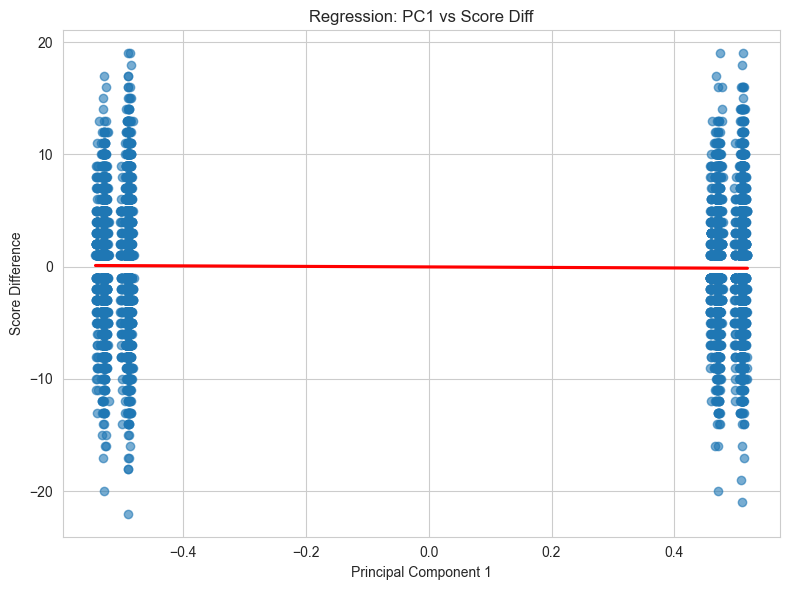

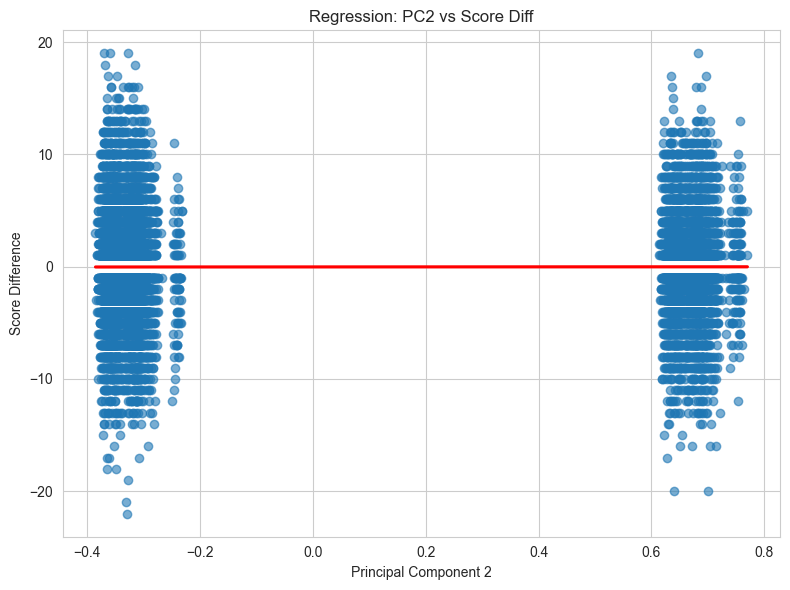

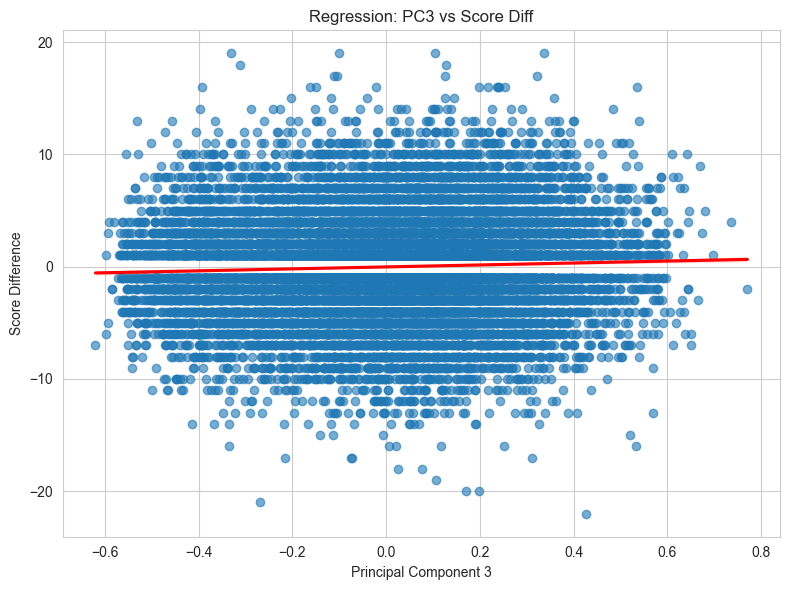

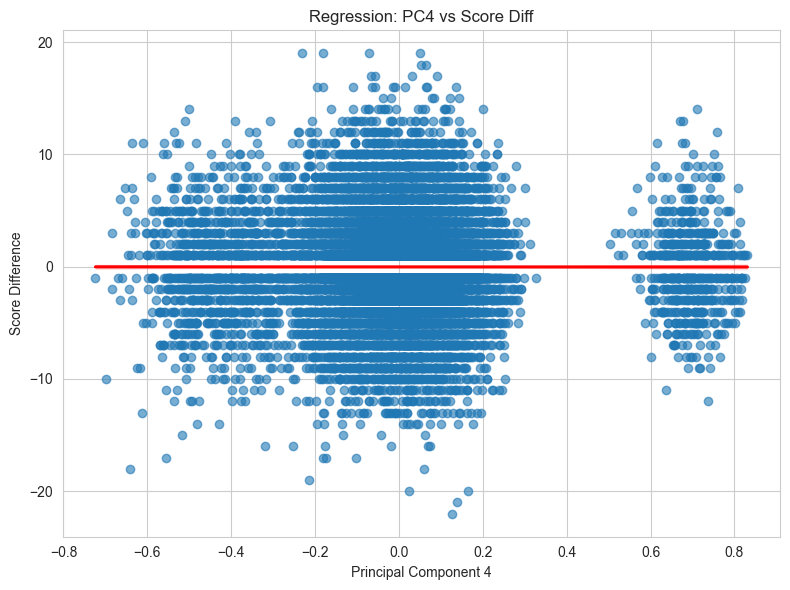

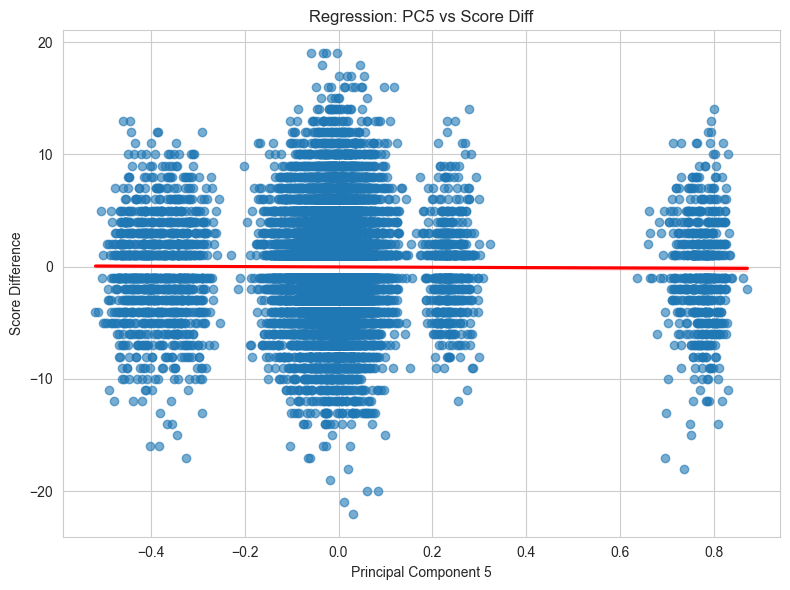

In [27]:
# plot
for pca_com in range(pca.n_components_):
    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))
    sns.regplot(x=X_pca[:, pca_com], y=y, scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
    plt.title(f"Regression: PC{pca_com + 1} vs Score Diff")
    plt.xlabel(f"Principal Component {pca_com + 1}")
    plt.ylabel("Score Difference")
    plt.tight_layout()
    plt.show()

In [28]:
print(X_pca.shape, y.shape)

(18242, 5) (18242,)


In [29]:
pca_col_names = [f"PCA_{i}" for i in range(X_pca.shape[1])]
df_data = pd.DataFrame(X_pca, columns=pca_col_names)
df_categorical = df[categorical_columns + [target]]
df_categorical = df_categorical.reset_index(drop=True)
df_data = df_data.reset_index(drop=True)
df_data = pd.concat([df_data, df_categorical], axis=1)
# # save df_data
df_data.to_csv("../CleanData/test_data_with_pca_05_09.csv", index=False)
#
df_data.head()

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,yearID,score_diff
0,0.514874,-0.312611,0.264669,-0.143511,-0.050517,2017,-2
1,-0.489846,-0.361521,0.089320,-0.005807,0.006902,2001,-5
2,0.508155,-0.313106,0.414423,0.730320,0.209396,2019,-2
3,0.509147,-0.317288,0.083837,-0.027977,0.018076,2004,4
4,0.506217,-0.295568,-0.058639,0.188474,-0.016128,1990,2
